# LLM Training Pipeline — Part 2: Supervised Fine-Tuning (SFT)

Stage 2 of 6. Loads `base_model.pt` from notebook 1 and fine-tunes it on an
instruction-formatted slice of TinyStories, using prompt-loss-masking so only
the response tokens contribute gradient. Produces `sft_model.pt`, the
checkpoint every later stage (reward model + PPO, DPO, evaluation,
RLVR/GRPO) fine-tunes or references as the frozen "reference" policy.

**How to use this notebook:**
- Read each theory section; keep `docs/llm_training_pipeline_reference.html`
  open in another tab (Section 4) for the full derivations.
- Code and tests are already implemented and verified — run cells top to
  bottom. Answer the **Question** cells yourself.

**Parts:**
1. Instruction Dataset Construction
2. Prompt-Loss-Masking
3. SFT Training Loop

In [1]:
import time, math, os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tokenizers import ByteLevelBPETokenizer

import sys
sys.path.insert(0, '../..')
from src.llm_pipeline.model import GPTConfig, GPTModel

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

CKPT_DIR = "../../data/checkpoints/llm_training_pipeline"
torch.manual_seed(0)

tokenizer = ByteLevelBPETokenizer(
    f"{CKPT_DIR}/tinystories_bpe-vocab.json",
    f"{CKPT_DIR}/tinystories_bpe-merges.txt",
)
EOT_ID = tokenizer.token_to_id('<|endoftext|>')

ckpt = torch.load(f"{CKPT_DIR}/base_model.pt", weights_only=False)
base_cfg = ckpt['config']
base_model = GPTModel(base_cfg).to(device)
base_model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded base_model.pt — {sum(p.numel() for p in base_model.parameters()):,} params")

Device: cuda


Loaded base_model.pt — 13,817,856 params


---
## Part 1: Instruction Dataset Construction

TinyStories has no built-in `(prompt, response)` structure. We synthesize one:
for each story, we heuristically extract a "topic" (a keyword the story is
actually about, from a fixed vocabulary of ~40 common TinyStories nouns), then
frame the story as the answer to `"Write a short story about {topic}:\n"`.
Stories where no keyword matches are dropped.

In [2]:
from datasets import load_dataset

TOPIC_KEYWORDS = [
    "dog", "cat", "girl", "boy", "forest", "ball", "tree", "bird", "star",
    "friend", "monster", "princess", "dragon", "robot", "garden", "park",
    "school", "castle", "rabbit", "mouse", "flower", "boat", "river",
    "mountain", "farm", "toy", "bear", "fish", "sun", "moon", "rain",
    "snow", "house", "family", "birthday", "picnic", "adventure", "magic",
    "kite", "puppy",
]

def extract_topic(story):
    lower = story.lower()
    for kw in TOPIC_KEYWORDS:
        if kw in lower:
            return kw
    return None

def format_sft_prompt(topic):
    return f"Write a short story about {topic}:\n"

print("Loading TinyStories (train[:50000]) for SFT pair construction...")
ds = load_dataset('roneneldan/TinyStories', split='train[:50000]')
sft_pairs = []
for x in ds:
    topic = extract_topic(x['text'])
    if topic is not None:
        sft_pairs.append((topic, x['text']))
print(f"{len(sft_pairs)} / {len(ds)} stories matched a topic keyword")

Loading TinyStories (train[:50000]) for SFT pair construction...


48316 / 50000 stories matched a topic keyword


In [3]:
# TEST 1: extraction determinism + prompt formatting + coverage sanity
assert extract_topic("A brave dog ran through the yard.") == "dog"
assert extract_topic("The weather was strange that day with no mentioned nouns.") is None
assert format_sft_prompt("dragon") == "Write a short story about dragon:\n"
assert len(sft_pairs) > 10000, f"expected >10000 matched pairs, got {len(sft_pairs)}"
for topic, story in sft_pairs[:3]:
    assert topic in story.lower()
print(f"TEST 1 PASSED — {len(sft_pairs)} pairs, extraction verified on samples")

TEST 1 PASSED — 48316 pairs, extraction verified on samples


### Question 1

`extract_topic` returns the **first** matching keyword found by scanning
`TOPIC_KEYWORDS` in a fixed order, even if a story matches several keywords
(e.g. a story about both a "dog" and a "park"). Is this a problem for
training a model to follow the `"Write a short story about {topic}:\n"`
instruction? What would you check to find out?

*Write your answer below:*

---
## Part 2: Prompt-Loss-Masking

`GPTModel.forward` already treats label value `-100` as "ignore this position"
(PyTorch's `F.cross_entropy` default `ignore_index`) — no model code changes
are needed. We only need a tokenizer function that builds the
`(input_ids, labels)` pair with prompt-token predictions masked out. This
follows the same shift-by-one convention as pretraining's `pack_into_blocks`:
`input_ids[i]` predicts `labels[i]`, where `labels[i]` is the *next* token
after `input_ids[i]` — so masking is applied to which *target* falls inside
the prompt, not which *input* position does.
See `docs/llm_training_pipeline_reference.html#s4` for why we mask at all.

In [4]:
def tokenize_sft_example(topic, story, tokenizer, eot_id, block_size):
    prompt_ids = tokenizer.encode(format_sft_prompt(topic)).ids
    completion_ids = tokenizer.encode(story).ids + [eot_id]
    full_ids = (prompt_ids + completion_ids)[: block_size + 1]
    n_prompt = min(len(prompt_ids), len(full_ids))
    n_real = len(full_ids)

    pad_len = (block_size + 1) - n_real
    full_ids = full_ids + [eot_id] * pad_len

    input_ids = full_ids[:-1]           # length block_size
    targets_raw = full_ids[1:]          # length block_size, shifted by one

    labels = []
    for i in range(block_size):
        target_pos = i + 1              # position in the original (unshifted) sequence
        if target_pos < n_prompt or target_pos >= n_real:
            labels.append(-100)         # target is a prompt token, or padding
        else:
            labels.append(targets_raw[i])

    return (
        torch.tensor(input_ids, dtype=torch.long),
        torch.tensor(labels, dtype=torch.long),
    )

BLOCK_SIZE = 256

In [5]:
# TEST 2: known mask boundary + masked-loss != full-loss
topic, story = "dog", "A dog ran fast."
prompt_len = len(tokenizer.encode(format_sft_prompt(topic)).ids)
input_ids, labels = tokenize_sft_example(topic, story, tokenizer, EOT_ID, BLOCK_SIZE)

assert input_ids.shape == (BLOCK_SIZE,)
assert labels.shape == (BLOCK_SIZE,)
# every target position before (prompt_len - 1) must be masked (predicting a prompt token)
assert torch.all(labels[: prompt_len - 1] == -100), "prompt-region targets not fully masked"
# the position right after the prompt should predict the first response token (not masked)
assert labels[prompt_len - 1].item() != -100, "first response token incorrectly masked"
print(f"TEST 2a PASSED — mask boundary correct (prompt_len={prompt_len})")

masked_logits, masked_loss = base_model(input_ids.unsqueeze(0).to(device), labels.unsqueeze(0).to(device))
unmasked_targets = torch.tensor(
    (tokenizer.encode(format_sft_prompt(topic)).ids + tokenizer.encode(story).ids + [EOT_ID])[1: BLOCK_SIZE + 1]
    + [EOT_ID] * max(0, BLOCK_SIZE - (len(tokenizer.encode(format_sft_prompt(topic)).ids + tokenizer.encode(story).ids + [EOT_ID]) - 1)),
    dtype=torch.long,
)[:BLOCK_SIZE].unsqueeze(0).to(device)
_, full_loss = base_model(input_ids.unsqueeze(0).to(device), unmasked_targets)

print(f"masked_loss={masked_loss.item():.4f}, full_loss(unmasked prompt+response)={full_loss.item():.4f}")
assert abs(masked_loss.item() - full_loss.item()) > 1e-4, "masked and unmasked loss should differ"
print("TEST 2b PASSED — masked loss differs from full (unmasked) loss")

TEST 2a PASSED — mask boundary correct (prompt_len=10)


masked_loss=5.4795, full_loss(unmasked prompt+response)=5.5168
TEST 2b PASSED — masked loss differs from full (unmasked) loss


### Question 2

The masking rule above checks `target_pos < n_prompt`, i.e. it masks based on
where the **predicted** token falls, not where the **input** token falls.
Concretely: the input token at the last prompt position (`input_ids[n_prompt - 1]`,
the `\n` after the prompt) is *not* masked as an input — it's fed into the
model normally. Why does that make sense, given the model needs to see the
whole prompt to generate the response?

*Write your answer below:*

---
## Part 3: SFT Training Loop

Fine-tunes a fresh copy of the base model for 400 steps (batch size 32) with
AdamW at a fixed LR of `3e-5` — roughly 10x below pretraining's peak LR (see
`docs/llm_training_pipeline_reference.html#s4` for the forgetting rationale).
No warmup/cosine schedule is used here: SFT runs few enough steps that a
constant low LR is simpler and sufficient. On an RTX 3070 this takes under a
minute.

In [6]:
import copy
sft_model = copy.deepcopy(base_model).to(device)

held_out = sft_pairs[-200:]
train_pairs = sft_pairs[:-200]
print(f"{len(train_pairs)} training pairs, {len(held_out)} held-out pairs")

def make_batch(pairs, batch_size):
    idx = torch.randint(0, len(pairs), (batch_size,))
    batch = [tokenize_sft_example(pairs[i][0], pairs[i][1], tokenizer, EOT_ID, BLOCK_SIZE) for i in idx]
    input_ids = torch.stack([b[0] for b in batch]).to(device)
    labels = torch.stack([b[1] for b in batch]).to(device)
    return input_ids, labels

48116 training pairs, 200 held-out pairs


In [7]:
max_steps = 400
lr = 3e-5
batch_size = 32

opt = torch.optim.AdamW(sft_model.parameters(), lr=lr)
losses = []
t0 = time.time()
for step in range(max_steps):
    input_ids, labels = make_batch(train_pairs, batch_size)
    logits, loss = sft_model(input_ids, labels)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
    opt.step()
    losses.append(loss.item())
    if step % 50 == 0 or step == max_steps - 1:
        print(f"step {step:4d} | loss {loss.item():.3f} | elapsed {time.time()-t0:.0f}s")

print(f"SFT training elapsed: {time.time()-t0:.1f}s")

step    0 | loss 3.226 | elapsed 2s


step   50 | loss 2.965 | elapsed 11s


step  100 | loss 3.231 | elapsed 19s


step  150 | loss 2.965 | elapsed 28s


step  200 | loss 3.043 | elapsed 37s


step  250 | loss 2.966 | elapsed 45s


step  300 | loss 2.961 | elapsed 54s


step  350 | loss 2.878 | elapsed 62s


step  399 | loss 2.953 | elapsed 70s
SFT training elapsed: 70.2s


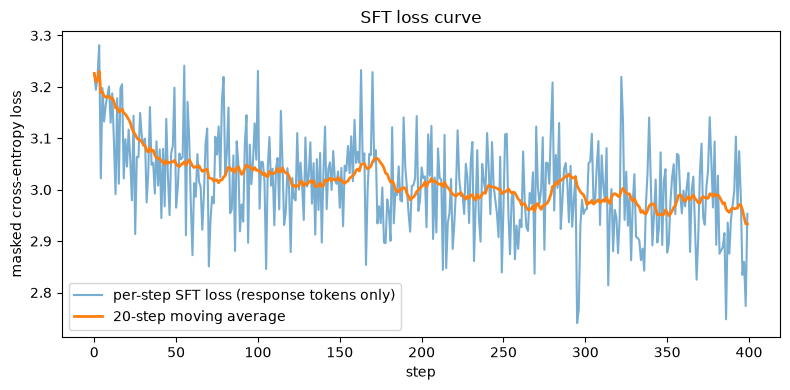

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(losses, alpha=0.6, label="per-step SFT loss (response tokens only)")
window = 20
smoothed = [sum(losses[max(0,i-window):i+1]) / len(losses[max(0,i-window):i+1]) for i in range(len(losses))]
plt.plot(smoothed, label=f"{window}-step moving average", linewidth=2)
plt.xlabel("step"); plt.ylabel("masked cross-entropy loss"); plt.title("SFT loss curve")
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# TEST 3: SFT loss decreased, and held-out perplexity improves over the base model
@torch.no_grad()
def held_out_avg_loss(model, pairs):
    model.eval()
    total = 0.0
    for topic, story in pairs:
        input_ids, labels = tokenize_sft_example(topic, story, tokenizer, EOT_ID, BLOCK_SIZE)
        _, loss = model(input_ids.unsqueeze(0).to(device), labels.unsqueeze(0).to(device))
        total += loss.item()
    return total / len(pairs)

first_20_avg = sum(losses[:20]) / 20
last_20_avg = sum(losses[-20:]) / 20
print(f"first-20-step avg loss: {first_20_avg:.3f}, last-20-step avg loss: {last_20_avg:.3f}")
assert last_20_avg < first_20_avg, "SFT loss did not decrease over training"

base_held_out_loss = held_out_avg_loss(base_model, held_out)
sft_held_out_loss = held_out_avg_loss(sft_model, held_out)
print(f"held-out masked loss — base: {base_held_out_loss:.3f} (PPL {math.exp(base_held_out_loss):.1f}), "
      f"sft: {sft_held_out_loss:.3f} (PPL {math.exp(sft_held_out_loss):.1f})")
assert sft_held_out_loss < base_held_out_loss, "SFT model did not improve held-out response-token perplexity"
print("TEST 3 PASSED — SFT loss decreased and held-out perplexity improved over base")

first-20-step avg loss: 3.147, last-20-step avg loss: 2.925


held-out masked loss — base: 3.078 (PPL 21.7), sft: 3.041 (PPL 20.9)
TEST 3 PASSED — SFT loss decreased and held-out perplexity improved over base


In [10]:
# Qualitative comparison: base vs SFT completions on held-out topics
sft_model.eval()
for topic in ["dragon", "picnic", "robot"]:
    prompt = format_sft_prompt(topic)
    prompt_ids = torch.tensor([tokenizer.encode(prompt).ids], device=device)
    base_out = base_model.generate(prompt_ids, max_new_tokens=40, temperature=0.8, top_k=40)
    sft_out = sft_model.generate(prompt_ids, max_new_tokens=40, temperature=0.8, top_k=40)
    print(f"=== topic: {topic} ===")
    print("BASE:", tokenizer.decode(base_out[0].tolist()))
    print("SFT :", tokenizer.decode(sft_out[0].tolist()))
    print()

=== topic: dragon ===
BASE: Write a short story about dragon:

The dragon was always brave. He thought that were best.<|endoftext|>Sam was feeling very happy. He wanted to learn something special. He wanted to show his mum a big, so he gave him
SFT : Write a short story about dragon:
Once upon a time, there was a little girl named Fluffy. She loved to play outside, but she couldn't find her friend to play with her, she saw a big slide with many things.



=== topic: picnic ===
BASE: Write a short story about picnic:

And that's to find a special flower. You can teach others how to bring it.â€

The little girl hugged it and said, â€œItâ€™t know. You are
SFT : Write a short story about picnic:
Jim was a very brave little girl. He always wanted to take her toys. One day, he saw a big box with a big, blue box. It was a little girl for her. She



=== topic: robot ===
BASE: Write a short story about robot:

The boy kept his new thing and he was so happy. He was so proud of his new friend. He felt a new thing he had a nice thing.<|endoftext|>Once there was a big garden
SFT : Write a short story about robot:
Once there was a little boy named Sam. Tom was a red toy. Tim was very excited to play with his toy car. He wanted to eat it and he said, "Look, Sue,



### Question 3

Compare the BASE and SFT completions above. The base model was never trained
on the `"Write a short story about {topic}:\n"` template at all — it will
either ignore the instruction and continue it as generic text, or coincidentally
produce something topical because TinyStories already contains that vocabulary.
Look specifically at whether the SFT model's response is more consistently
*about* the stated topic than the base model's. Does the held-out perplexity
number from TEST 3 alone tell you this, or did you need to read the actual
generations to know?

*Write your answer below:*

In [11]:
ckpt_path = f"{CKPT_DIR}/sft_model.pt"
torch.save({'model_state_dict': sft_model.state_dict(), 'config': base_cfg}, ckpt_path)
print(f"Saved SFT checkpoint to {ckpt_path}")

Saved SFT checkpoint to ../../data/checkpoints/llm_training_pipeline/sft_model.pt
